In [126]:
import pandas as pd
import numpy as np
data = pd.read_csv('titanic3.csv')

In [127]:
data.dtypes

pclass         int64
survived       int64
name          object
sex           object
age          float64
sibsp          int64
parch          int64
ticket        object
fare         float64
cabin         object
embarked      object
boat          object
body         float64
home.dest     object
dtype: object

In [128]:
data.replace('?', np.nan, inplace=True)

In [129]:
na_rows = pd.isna(data['age'])
question_mark_rows = data[na_rows]

<Axes: xlabel='survived', ylabel='fare'>

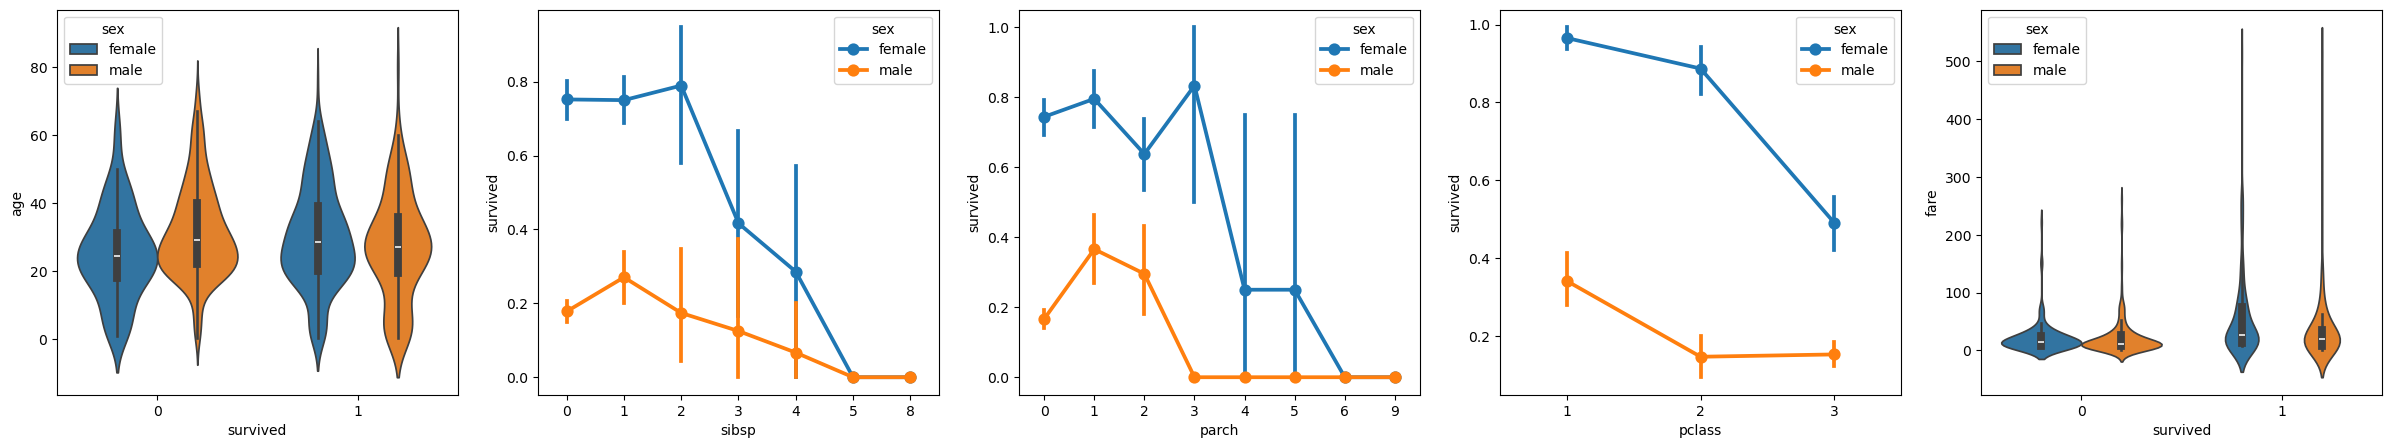

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(ncols=5, figsize=(30,5))
sns.violinplot(x="survived", y="age", hue="sex", data=data, ax=axs[0])
sns.pointplot(x="sibsp", y="survived", hue="sex", data=data, ax=axs[1])
sns.pointplot(x="parch", y="survived", hue="sex", data=data, ax=axs[2])
sns.pointplot(x="pclass", y="survived", hue="sex", data=data, ax=axs[3])
sns.violinplot(x="survived", y="fare", hue="sex", data=data, ax=axs[4])


In [131]:
data['sex'] = data['sex'].replace({"male": 1, "female": 0})
data['sex'] = data['sex'].astype("int64")

/var/folders/6l/0ln54yv53l35x35zsrv0syb40000gn/T/ipykernel_3004/1106382083.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['sex'] = data['sex'].replace({"male": 1, "female": 0})


In [132]:
def show_corr(data_to_show):
  corr_matrix = data.corr(numeric_only=True)

  # Set up the plot
  plt.figure(figsize=(10, 8))
  sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

  plt.title("Correlation Heatmap")
  plt.show()


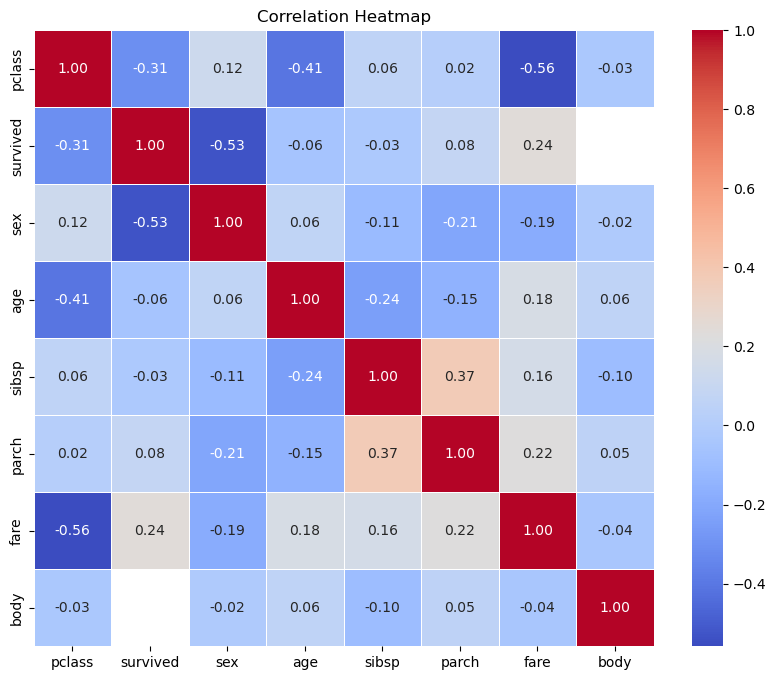

In [133]:
# Compute correlation
show_corr(data)


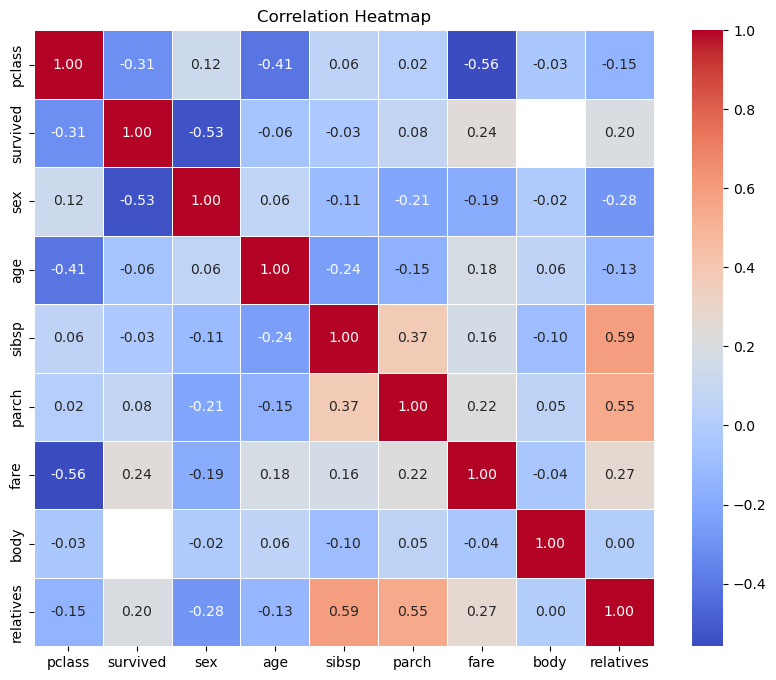

In [134]:
data['relatives'] = data.apply (lambda row: int((row['sibsp'] + row['parch']) > 0), axis=1)
show_corr(data)


In [135]:
data = data[['sex', 'pclass','age','relatives','fare','survived']].dropna()


In [136]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data[['sex', 'pclass','age','relatives','fare']], data['survived'], test_size=0.2, random_state=42) 


In [137]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(x_train)
X_test = sc.transform(x_test)

In [138]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [139]:
from sklearn import metrics
predict_test = nb_model.predict(X_test)
print(metrics.accuracy_score(y_test, predict_test))


0.7033492822966507


In [140]:
from keras.models import Sequential
from keras.layers import Dense

nn_model = Sequential()


In [141]:
from keras.layers import Input

nn_model.add(Input(shape=(5,)))
nn_model.add(Dense(5, kernel_initializer='uniform', activation='relu'))
nn_model.add(Dense(5, kernel_initializer='uniform', activation='relu'))
nn_model.add(Dense(1, kernel_initializer='uniform', activation='sigmoid'))


In [142]:
nn_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66 (264.00 B)

 Trainable params: 66 (264.00 B)

 Non-trainable params: 0 (0.00 B)

In [143]:
nn_model.compile(optimizer="adam", loss='binary_crossentropy', metrics=['accuracy'])
nn_model.fit(X_train, y_train, batch_size=32, epochs=50)


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step - accuracy: 0.5644 - loss: 0.6925
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - accuracy: 0.5799 - loss: 0.6907
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - accuracy: 0.5792 - loss: 0.6873
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.5772 - loss: 0.6800
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - accuracy: 0.5966 - loss: 0.6644
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - accuracy: 0.5834 - loss: 0.6465
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step - accuracy: 0.5953 - loss: 0.6191
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step - accuracy: 0.6322 - loss: 0.5890
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step - accuracy: 0.7577 - loss: 0.5728
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step - accuracy: 0.7916 - loss: 0.5537
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - accuracy: 0.7914 - loss: 0.5276
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step

In [144]:
y_pred = np.rint(nn_model.predict(X_test).flatten())
print(metrics.accuracy_score(y_test, y_pred))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
0.7368421052631579


In [146]:
# Column names as in training
columns = ['sex', 'pclass', 'age', 'relatives', 'fare']

# New passenger input
new_passenger = pd.DataFrame([[0, 1, 35, 1, 80.0]], columns=columns)

# Scale properly (no warning)
new_scaled = sc.transform(new_passenger)

# Predict as before
nb_pred = nb_model.predict(new_scaled)[0]

# Predict using Neural Network
nn_prob = nn_model.predict(new_scaled)[0][0]
nn_pred = 1 if nn_prob >= 0.5 else 0

# Show results
print("🧠 Neural Network Prediction:", "✅ Survived" if nn_pred == 1 else "❌ Not Survived", f"(prob: {nn_prob:.2f})")
print("🪶 GaussianNB Prediction:", "✅ Survived" if nb_pred == 1 else "❌ Not Survived")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
🧠 Neural Network Prediction: ✅ Survived (prob: 0.95)
🪶 GaussianNB Prediction: ✅ Survived
